- Ice shelf Basal Melt
    * Description: Antarctic ice shelf basal melt rates from 1997 to 2021. All code required to reproduce the results presented in Davison et al. Annual mass budget of Antarctic ice shelves from 1997 to 2021. Also provided are the ice shelf masks and 500x500 m basal melt rates.
    * Original Data Source: https://zenodo.org/records/8052519
    * Reference: https://www.science.org/doi/10.1126/sciadv.adi0186
    * OSC entry: https://opensciencedata.esa.int/products/antarctic-ice-shelf-melt-rates/collection
    * License: CC-BY-4.0
    * Repo Folder: ./datasets/basal_melt

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from rasterio.windows import from_bounds


# use remote paths
raster_path = Path("https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/basal_melt/basal_melt_map_racmo_firn_air_corrected.tif")

bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
file = 'OSCAssets/polar_cube_datasets/basal_melt/basal_melt_timeseries_polygons_union_and_intersection.parquet'

In [2]:

gdf = gpd.read_parquet(
    f"{bucket}{file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    }
).set_geometry("geometry_union")

In [3]:
# select shelf to plot
shelf_name = "Aviator"

In [4]:
# read shelf melt time series
# gdf = gpd.read_parquet(parquet_path)
gdf["time"] = pd.to_datetime(gdf["time"])
shelf = gdf[gdf.name.str.casefold() == shelf_name.casefold()].sort_values("time").copy()


# create masks for the target and all other shelves
all_masks = gdf[["name", "geometry_union"]].drop_duplicates("name")
outline = shelf[["name", "geometry_union"]].drop_duplicates("name")

In [5]:
# open raster and read the data around a target shelf
with rasterio.open(raster_path) as src:
    all_masks = all_masks.to_crs(src.crs)
    outline = outline.to_crs(src.crs)
    x0, y0, x1, y1 = outline.total_bounds
    dx, dy = (x1 - x0) * 0.25, (y1 - y0) * 0.25
    x0 = max(x0 - dx, src.bounds.left)
    y0 = max(y0 - dy, src.bounds.bottom)
    x1 = min(x1 + dx, src.bounds.right)
    y1 = min(y1 + dy, src.bounds.top)
    win = from_bounds(x0, y0, x1, y1, src.transform).round_offsets().round_lengths()
    melt = np.ma.masked_invalid(src.read(1, window=win, masked=True).astype(float))
    l, b, r, t = rasterio.windows.bounds(win, src.transform)

# limit the values
vals = melt.compressed()
if vals.size and vals.min() < 0 < vals.max():
    lim = np.nanpercentile(np.abs(vals), 98)
    cmap, vmin, vmax = "RdBu_r", -lim, lim
else:
    cmap = "magma"
    vmin = np.nanpercentile(vals, 2) if vals.size else None
    vmax = np.nanpercentile(vals, 98) if vals.size else None

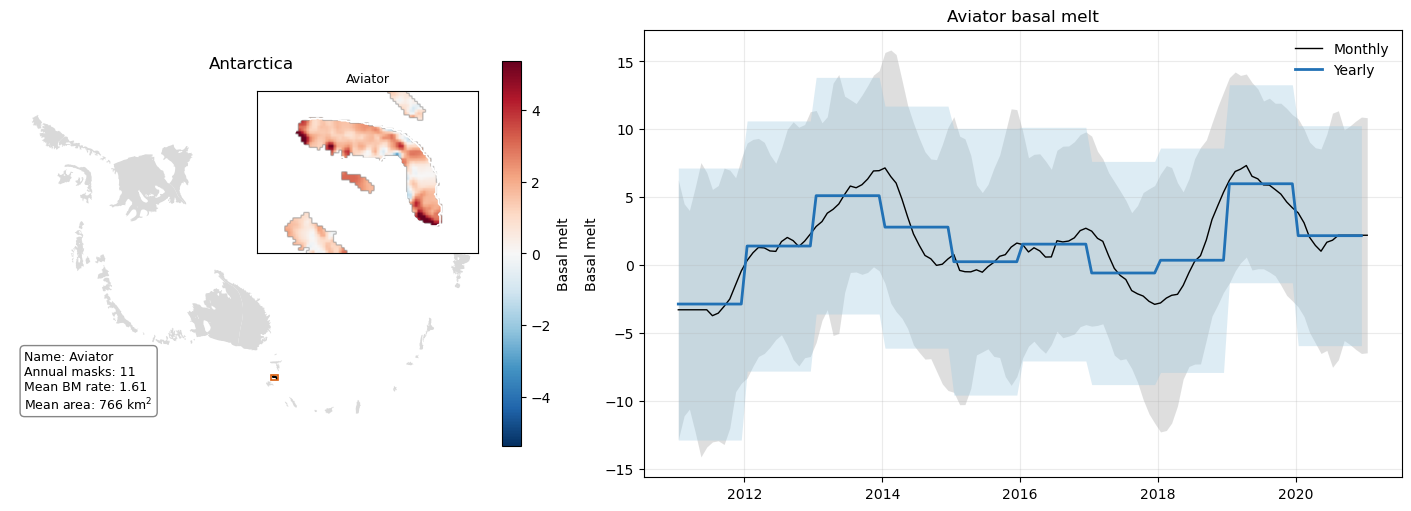

In [ ]:
# plot data the shelf, the firn rate basal melt, and the time series

fig, (ax_map, ax_ts) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.4, 2.2]}, constrained_layout=True)

all_masks.plot(ax=ax_map, color="0.85", edgecolor="none")
outline.plot(ax=ax_map, color="#3182bd", edgecolor="black", linewidth=0.7)
ax_map.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="#d95f0e", linewidth=1.2))
ax_map.set_title("Antarctica")
ax_map.set_axis_off()

inset = inset_axes(ax_map, width="46%", height="46%", loc="upper right", borderpad=1)
im = inset.imshow(melt, extent=(l, r, b, t), origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)
outline.plot(ax=inset, facecolor="none", edgecolor="white", linewidth=1.2)
inset.set_xlim(x0, x1)
inset.set_ylim(y0, y1)
inset.set_xticks([])
inset.set_yticks([])
inset.set_title(shelf_name, fontsize=9)
fig.colorbar(im, ax=ax_map, fraction=0.04, pad=0.02, label="Basal melt")

ax_map.text(
    0.03,
    0.05,
    f"Name: {shelf_name}\nAnnual masks: {shelf.time.dt.year.nunique()}\nMean BM rate: {shelf.bm_yearly.mean():.2f}\nMean area: {shelf.area_km2.mean():,.0f} km$^2$",
    transform=ax_map.transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.5", alpha=0.95),
)

ax_ts.fill_between(shelf.time, shelf.bm_monthly - shelf.bm_monthly_errors, shelf.bm_monthly + shelf.bm_monthly_errors, color="0.75", alpha=0.5, linewidth=0)
ax_ts.plot(shelf.time, shelf.bm_monthly, color="black", linewidth=1.0, label="Monthly")
ax_ts.fill_between(shelf.time, shelf.bm_yearly - shelf.bm_yearly_errors, shelf.bm_yearly + shelf.bm_yearly_errors, color="#9ecae1", alpha=0.35, linewidth=0)
ax_ts.plot(shelf.time, shelf.bm_yearly, color="#2171b5", linewidth=2.0, label="Yearly")
ax_ts.set_title(f"{shelf_name} basal melt")
ax_ts.set_ylabel("Basal melt")
ax_ts.xaxis.set_major_locator(mdates.YearLocator(2))
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_ts.grid(True, alpha=0.25)
ax_ts.legend(loc="best", frameon=False)